# 6.36 - CertCF Sparsity Lambda Ablation

Minimal analysis of the completed CertCF sweep in `final_benchmark_noface_certcf_shrink_sparsity.parquet`, with `final_benchmark_noface_certcf_shrink_sparsity_lambda0.parquet` loaded as the matching `lambda=0` run.


In [1]:
from __future__ import annotations

from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

SPARSE_RESULT_PATH = ROOT / 'results/final_benchmark_noface_certcf_shrink_sparsity.parquet'
LAMBDA_ZERO_RESULT_PATH = ROOT / 'results/final_benchmark_noface_certcf_shrink_sparsity_lambda0.parquet'
SELECTED_ALPHA = 0.20
L0_TOL = 1e-6

DATASET_ORDER = [
    'adult',
    'compas',
    'german_credit',
    'give_me_some_credit',
    'heloc',
    'lending_club',
    'wisconsin_breast_cancer',
]

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120})

print('sparse sweep:', SPARSE_RESULT_PATH)
print('exists:', SPARSE_RESULT_PATH.exists())
print('lambda=0 baseline:', LAMBDA_ZERO_RESULT_PATH)
print('exists:', LAMBDA_ZERO_RESULT_PATH.exists())


sparse sweep: /home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/final_benchmark_noface_certcf_shrink_sparsity.parquet
exists: True
lambda=0 baseline: /home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/final_benchmark_noface_certcf_shrink_sparsity_lambda0.parquet
exists: True


## Load Sweep

In [2]:
SPARSE_RUN_RE = re.compile(r'eps_alpha=([0-9.]+)-sparsity_lambda=([0-9.]+)')
ALPHA_RE = re.compile(r'eps_alpha=([0-9.]+)')


def parse_sparse_hparams(run_name: str) -> tuple[float, float]:
    match = SPARSE_RUN_RE.search(str(run_name))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))


def parse_alpha(run_name: str) -> float:
    match = ALPHA_RE.search(str(run_name))
    if not match:
        return np.nan
    return float(match.group(1))


def indexed_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    cols = [c for c in df.columns if c.startswith(prefix)]
    return sorted(cols, key=lambda c: int(c.rsplit('_', 1)[1]))


def add_l0_count(df: pd.DataFrame, tol: float = L0_TOL) -> pd.DataFrame:
    out = df.copy()
    out['l0_count'] = np.nan
    for dataset_name in DATASET_ORDER:
        mask = out['dataset'].astype(str).eq(dataset_name)
        ds = out.loc[mask]
        if ds.empty:
            continue
        orig_cols = [c for c in indexed_columns(ds, 'x_orig_') if ds[c].notna().any()]
        cf_cols = [f"x_cf_{c.rsplit('_', 1)[1]}" for c in orig_cols]
        if not orig_cols or not set(cf_cols).issubset(out.columns):
            continue
        x_orig = ds[orig_cols].to_numpy(dtype=float)
        x_cf = ds[cf_cols].to_numpy(dtype=float)
        finite = np.isfinite(x_orig).all(axis=1) & np.isfinite(x_cf).all(axis=1)
        l0 = np.full(len(ds), np.nan)
        l0[finite] = (np.abs(x_cf[finite] - x_orig[finite]) > tol).sum(axis=1)
        out.loc[mask, 'l0_count'] = l0
    return out


def prepare_certcf_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df[df['method'].astype(str).eq('certcf')].copy()
    out['success_bool'] = out['success'].fillna(False).astype(bool)
    out['dataset'] = pd.Categorical(out['dataset'].astype(str), DATASET_ORDER, ordered=True)
    return out


def load_sparse_sweep(path: Path = SPARSE_RESULT_PATH) -> pd.DataFrame:
    df = prepare_certcf_frame(pd.read_parquet(path))
    parsed = df['run_name'].map(parse_sparse_hparams)
    df['alpha'] = [p[0] for p in parsed]
    df['sparsity_lambda'] = [p[1] for p in parsed]
    df['lambda_source'] = 'reweighted_l1'
    return df


def load_lambda_zero_baseline(path: Path = LAMBDA_ZERO_RESULT_PATH) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = prepare_certcf_frame(pd.read_parquet(path))
    parsed = df['run_name'].map(parse_sparse_hparams)
    df['alpha'] = [p[0] for p in parsed]
    df['sparsity_lambda'] = [p[1] for p in parsed]
    df['lambda_source'] = 'reweighted_l1_lambda0'
    return df


def load_sweep() -> pd.DataFrame:
    df = pd.concat([load_lambda_zero_baseline(), load_sparse_sweep()], ignore_index=True, sort=False)
    df = add_l0_count(df)
    return df.sort_values(['dataset', 'alpha', 'sparsity_lambda', 'query_idx'], ignore_index=True)


CERTCF_DF = load_sweep()
display(pd.DataFrame({
    'rows': [len(CERTCF_DF)],
    'datasets': [CERTCF_DF['dataset'].nunique()],
    'alphas': [sorted(CERTCF_DF['alpha'].dropna().unique())],
    'lambdas': [sorted(CERTCF_DF['sparsity_lambda'].dropna().unique())],
    'runs': [CERTCF_DF['run_name'].nunique()],
}))

display(
    CERTCF_DF[['alpha', 'sparsity_lambda', 'lambda_source', 'run_name']]
    .drop_duplicates()
    .sort_values(['alpha', 'sparsity_lambda'])
    .reset_index(drop=True)
)


,rows,datasets,alphas,lambdas,runs
0,214785,7,"[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]","[0.0, 0.1, 0.2, 0.5, 1.0]",45


,alpha,sparsity_lambda,lambda_source,run_name
0,0.1000,0.0000,reweighted_l1_lambda0,certcf_backward_shrink_sparsity_lambda0_eps_al...
1,0.1000,0.1000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.1-...
2,0.1000,0.2000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.1-...
3,0.1000,0.5000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.1-...
4,0.1000,1.0000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.1-...
5,0.1500,0.0000,reweighted_l1_lambda0,certcf_backward_shrink_sparsity_lambda0_eps_al...
6,0.1500,0.1000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.15...
7,0.1500,0.2000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.15...
8,0.1500,0.5000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.15...
9,0.1500,1.0000,reweighted_l1,certcf_backward_shrink_sparsity_eps_alpha=0.15...


## Dataset-Averaged Summary

In [3]:
def summarize_dataset_run(group: pd.DataFrame) -> pd.Series:
    ok = group[group['success_bool']]
    return pd.Series({
        'n_total': len(group),
        'n_success': int(group['success_bool'].sum()),
        'validity_pct': 100.0 * float(group['success_bool'].mean()),
        'l1_mean': float(ok['l1_distance'].mean()) if not ok.empty else np.nan,
        'l1_median': float(ok['l1_distance'].median()) if not ok.empty else np.nan,
        'l0_mean': float(ok['l0_count'].mean()) if not ok.empty else np.nan,
        'selection_score_mean': float(pd.to_numeric(ok.get('meta__sparsity_selection_score'), errors='coerce').mean()) if not ok.empty else np.nan,
        'sparsity_solver_calls_mean': float(pd.to_numeric(group.get('meta__sparsity_solver_calls'), errors='coerce').mean()),
    })


DATASET_RUN_DF = (
    CERTCF_DF
    .groupby(['dataset', 'alpha', 'sparsity_lambda', 'run_name'], observed=True)
    .apply(summarize_dataset_run)
    .reset_index()
)

AGG_DF = (
    DATASET_RUN_DF
    .groupby(['alpha', 'sparsity_lambda'], observed=True)
    .agg(
        n_datasets=('dataset', 'nunique'),
        validity_pct=('validity_pct', 'mean'),
        l1_mean=('l1_mean', 'mean'),
        l1_median=('l1_median', 'mean'),
        l0_mean=('l0_mean', 'mean'),
        selection_score_mean=('selection_score_mean', 'mean'),
        sparsity_solver_calls_mean=('sparsity_solver_calls_mean', 'mean'),
    )
    .reset_index()
)

display(AGG_DF.sort_values(['alpha', 'sparsity_lambda']).round(4))

/tmp/ipykernel_195272/878896240.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_dataset_run)


,alpha,sparsity_lambda,n_datasets,validity_pct,l1_mean,l1_median,l0_mean,selection_score_mean,sparsity_solver_calls_mean
0,0.1000,0.0000,7,100.0000,7.6424,6.9596,11.4592,7.6424,1.0000
1,0.1000,0.1000,7,100.0000,7.5475,6.8343,9.0780,8.3545,3.0000
2,0.1000,0.2000,7,100.0000,7.5674,6.8674,8.9293,9.1522,3.0000
3,0.1000,0.5000,7,100.0000,7.6608,7.0447,8.6743,11.4929,3.0000
4,0.1000,1.0000,7,100.0000,7.7385,7.1041,8.5555,15.2856,3.0000
5,0.1500,0.0000,7,100.0000,7.5627,6.8686,11.4540,7.5627,1.0000
6,0.1500,0.1000,7,100.0000,7.4668,6.7478,8.7170,8.2374,3.0000
7,0.1500,0.2000,7,100.0000,7.4874,6.8423,8.5807,9.0016,3.0000
8,0.1500,0.5000,7,100.0000,7.5792,6.8902,8.3030,11.2247,3.0000
9,0.1500,1.0000,7,100.0000,7.6592,7.0217,8.1924,14.8394,3.0000


## Lambda Effect

/tmp/ipykernel_195272/166864191.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


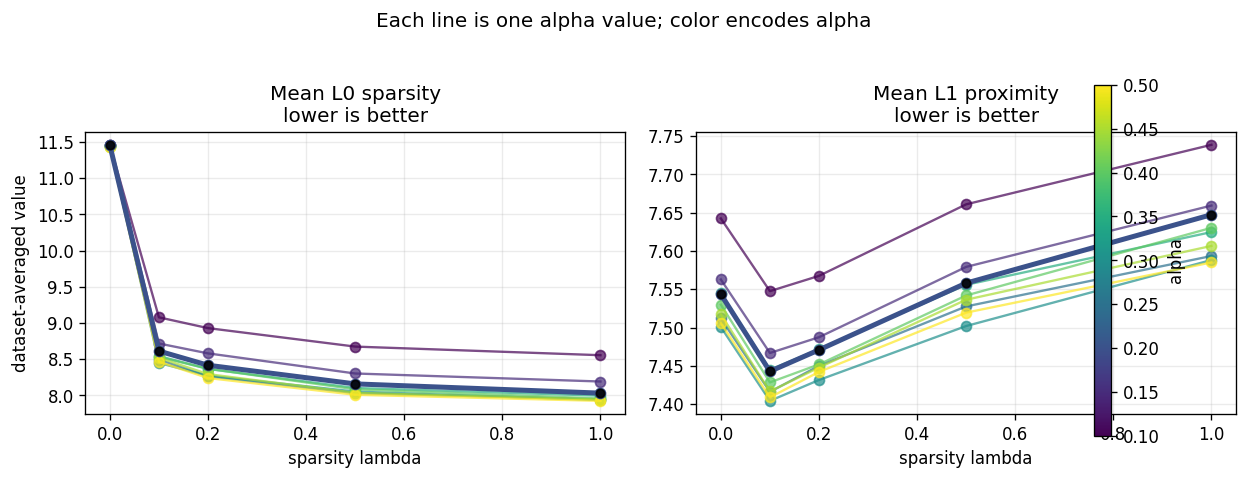

In [4]:
def plot_lambda_curves(summary_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True)
    metrics = [
        ('l0_mean', 'Mean L0 sparsity', 'lower is better'),
        ('l1_mean', 'Mean L1 proximity', 'lower is better'),
    ]
    alphas = np.array(sorted(summary_df['alpha'].dropna().unique()), dtype=float)
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(vmin=float(alphas.min()), vmax=float(alphas.max()))

    for alpha in alphas:
        alpha_df = summary_df[np.isclose(summary_df['alpha'], alpha)].sort_values('sparsity_lambda')
        is_selected = np.isclose(alpha, SELECTED_ALPHA)
        color = cmap(norm(alpha))
        lw = 3.0 if is_selected else 1.4
        line_alpha = 1.0 if is_selected else 0.70
        zorder = 5 if is_selected else 2
        for ax, (metric, title, subtitle) in zip(axes, metrics):
            x_values = alpha_df['sparsity_lambda'].to_numpy(dtype=float)
            y_values = alpha_df[metric].to_numpy(dtype=float)
            ax.plot(
                x_values,
                y_values,
                marker='o',
                color=color,
                linewidth=lw,
                alpha=line_alpha,
                zorder=zorder,
            )
            if is_selected:
                ax.plot(
                    x_values,
                    y_values,
                    marker='o',
                    color='black',
                    linewidth=0,
                    markersize=5,
                    alpha=0.85,
                    zorder=zorder + 1,
                )
            ax.set_title(f'{title}\n{subtitle}')
            ax.set_xlabel('sparsity lambda')
            ax.grid(True, alpha=0.25)

    axes[0].set_ylabel('dataset-averaged value')
    fig.suptitle('Each line is one alpha value; color encodes alpha', y=1.04)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.035, pad=0.02)
    cbar.set_label('alpha')
    fig.tight_layout()
    return fig, axes


plot_lambda_curves(AGG_DF);


In [5]:
PAPER_ROOT = Path('/home/gabrielepintus/Documents/github/CertCF')
OUT_PATH = PAPER_ROOT / 'sections/plots/data/certcf_lambda_ablation.csv'

latex_df = (
    AGG_DF[['alpha', 'sparsity_lambda', 'l0_mean', 'l1_mean']]
    .copy()
    .sort_values(['alpha', 'sparsity_lambda'])
)

latex_df.to_csv(OUT_PATH, index=False)
OUT_PATH


PosixPath('/home/gabrielepintus/Documents/github/CertCF/sections/plots/data/certcf_lambda_ablation.csv')